Cell 1 – Imports & Utils

In [158]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelBinarizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import NearestNeighbors
from scipy.stats import mode

import warnings, random
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

def discretise_quantiles(df: pd.DataFrame, q: int = 10) -> pd.DataFrame:
    out = df.copy()
    for col in out.select_dtypes(include="number").columns:
        out[col] = pd.qcut(out[col], q=q, duplicates="drop").astype(str)
    return out


def gmean_from_cm(cm: np.ndarray) -> float:
    TP = np.diag(cm)
    FN = np.sum(cm, axis=1) - TP
    sens = TP / (TP + FN + 1e-8)
    return np.prod(sens) ** (1 / len(sens))


Cell 2 – Load & Clean Covid19HDDT dataset

In [159]:
import pandas as pd

covid      = pd.read_csv("/content/Covid19HDDT.csv")
label_col  = "label"


corr2lbl    = covid.drop(columns=label_col).apply(lambda c: c.corr(covid[label_col])).abs()
leaky_feats = corr2lbl[corr2lbl > 0.5].index.tolist()
print("Dropping leaky features:", leaky_feats)

X_raw  = covid.drop(columns=leaky_feats + [label_col])
X_disc = discretise_quantiles(X_raw, q=10)

covid_clean = pd.concat([X_disc, covid[label_col]], axis=1)

minority_cls           = covid_clean[label_col].value_counts().idxmin()
covid_bin              = covid_clean.copy()
covid_bin["binary_label"] = (covid_bin[label_col] == minority_cls).astype(int)
covid_bin.drop(columns=[label_col], inplace=True)

FEAT_NAMES = covid_bin.drop(columns=["binary_label"]).columns.tolist()


Dropping leaky features: ['province', 'city', 'elementary_school_count', 'kindergarten_count', 'university_count', 'academy_ratio', 'elderly_population_ratio', 'elderly_alone_ratio', 'nursing_home_count']


Cell 3 – HDDT implementation (categorical)

In [160]:
class HDDTNode:
    def __init__(self, depth=0, max_depth=None):
        self.depth, self.max_depth = depth, max_depth
        self.feature = self.threshold = None
        self.left = self.right = None
        self.label = None
        self.pos_ratio = None

    def is_leaf(self): return self.label is not None


def hellinger_distance(X, y, feat_idx):
    values = np.unique(X[:, feat_idx])
    n_pos, n_neg = (y == 1).sum(), (y == 0).sum()
    hd = 0.0
    for v in values:
        p_pos = ((X[:, feat_idx] == v) & (y == 1)).sum() / (n_pos + 1e-12)
        p_neg = ((X[:, feat_idx] == v) & (y == 0)).sum() / (n_neg + 1e-12)
        hd += (np.sqrt(p_pos) - np.sqrt(p_neg)) ** 2
    return np.sqrt(hd)


def build_hddt(X, y, depth=0, max_depth=None):

    node = HDDTNode(depth, max_depth)


    if len(np.unique(y)) == 1 or (max_depth is not None and depth >= max_depth):
        node.label, node.pos_ratio = np.bincount(y).argmax(), y.mean()
        return node


    best_feat, best_hd = None, -1
    for f in range(X.shape[1]):
        hd = hellinger_distance(X, y, f)
        if hd > best_hd: best_hd, best_feat = hd, f
    if best_feat is None:
        node.label, node.pos_ratio = np.bincount(y).argmax(), y.mean()
        return node

    node.feature = best_feat
    cats = np.unique(X[:, best_feat])
    node.threshold = cats[0]

    left_idx  = X[:, best_feat] == node.threshold
    right_idx = ~left_idx
    if left_idx.sum() == 0 or right_idx.sum() == 0:
        node.label, node.pos_ratio = np.bincount(y).argmax(), y.mean()
        return node

    node.left  = build_hddt(X[left_idx],  y[left_idx],  depth+1, max_depth)
    node.right = build_hddt(X[right_idx], y[right_idx], depth+1, max_depth)
    node.pos_ratio = y.mean()
    return node


def predict_leaf(node, sample):
    while not node.is_leaf():
        node = node.left if sample[node.feature] == node.threshold else node.right
    return node.label, node.pos_ratio


def hddt_predict(X, tree):
    lbls, probs = zip(*(predict_leaf(tree, s) for s in X))
    return np.array(lbls), np.array(probs)


Cell 4 – Binary HDDT : 10 runs (Depth = 5)   

In [161]:
X_bin = covid_bin.drop(columns=["binary_label"]).values
y_bin = covid_bin["binary_label"].values.astype(int)

metric_runs = {m: [] for m in ["prec", "rec", "f1", "auc", "g"]}

for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_bin, y_bin, test_size=0.30, stratify=y_bin, random_state=seed
    )


    tree = build_hddt(X_tr, y_tr, max_depth=5)


    y_pred, y_prob = hddt_predict(X_te, tree)


    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)
    g    = gmean_from_cm(confusion_matrix(y_te, y_pred))


    for k, v in zip(metric_runs, [prec, rec, f1, auc, g]):
        metric_runs[k].append(v)


print({k: (np.mean(v), np.std(v)) for k, v in metric_runs.items()})

X_bin = covid_bin.drop(columns=["binary_label"]).values
y_bin = covid_bin["binary_label"].values.astype(int)

metric_runs = {m: [] for m in ["prec", "rec", "f1", "auc", "g"]}
for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X_bin, y_bin, test_size=0.3, stratify=y_bin, random_state=seed)
    tree = build_hddt(X_tr, y_tr, max_depth=5)
    y_pred, y_prob = hddt_predict(X_te, tree)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob)
    g    = gmean_from_cm(confusion_matrix(y_te, y_pred))
    for k,v in zip(metric_runs, [prec, rec, f1, auc, g]):
        metric_runs[k].append(v)
for k, vals in metric_runs.items():
    mean = np.mean(vals) * 100
    std  = np.std(vals)  * 100
    print(f"{k.upper():>4}:  {mean:5.1f}%  ± {std:4.1f}%")

{'prec': (np.float64(1.0), np.float64(0.0)), 'rec': (np.float64(1.0), np.float64(0.0)), 'f1': (np.float64(1.0), np.float64(0.0)), 'auc': (np.float64(1.0), np.float64(0.0)), 'g': (np.float64(0.9999999999954767), np.float64(1.1102230246251565e-16))}
PREC:  100.0%  ±  0.0%
 REC:  100.0%  ±  0.0%
  F1:  100.0%  ±  0.0%
 AUC:  100.0%  ±  0.0%
   G:  100.0%  ±  0.0%


Cell 5 – OVA / OVO helpers (use same train/test)

In [162]:
from itertools import combinations
from sklearn.preprocessing import LabelBinarizer

#  One‑Versus‑All (OVA)
def train_ova(X_tr, y_tr, max_depth: int = 5):

    models = {}
    for c in np.unique(y_tr):
        y_bin = (y_tr == c).astype(int)
        models[c] = build_hddt(X_tr, y_bin, max_depth=max_depth)
    return models


def predict_ova(X_te, models: dict):

    prob_mat = []
    for c, tree in models.items():
        _, prob = hddt_predict(X_te, tree)
        prob_mat.append(prob)
    prob_mat = np.stack(prob_mat, axis=1)
    best_idx = np.argmax(prob_mat, axis=1)
    classes  = list(models.keys())
    return np.array([classes[i] for i in best_idx])


#  One‑Versus‑One (OVO)
def train_ovo(X_tr, y_tr, max_depth: int = 5):

    pairs = {}
    for c1, c2 in combinations(np.unique(y_tr), 2):
        idx      = (y_tr == c1) | (y_tr == c2)
        X_pair   = X_tr[idx]
        y_pair   = y_tr[idx]
        y_binary = (y_pair == c1).astype(int)
        pairs[(c1, c2)] = build_hddt(X_pair, y_binary, max_depth=max_depth)
    return pairs


def predict_ovo(X_te, models: dict, classes: np.ndarray):

    votes = np.zeros((X_te.shape[0], len(classes)))
    class_to_idx = {c: i for i, c in enumerate(classes)}

    for (c1, c2), tree in models.items():
        y_pred, _ = hddt_predict(X_te, tree)
        winners   = np.where(y_pred == 1, c1, c2)
        for i, w in enumerate(winners):
            votes[i, class_to_idx[w]] += 1

    return np.array([classes[i] for i in votes.argmax(axis=1)])


Cell 6 – Evaluate OVA/OVO depth sweep

In [163]:
X_full = covid_clean.drop(columns=[label_col]).values
y_full = covid_clean[label_col].values


X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.30, stratify=y_full, random_state=42
)

for depth in [2, 3, 4, 5]:
    #  OVA
    print(f"\n--- OVA  |  max_depth = {depth} ---")
    ova_models = train_ova(X_tr, y_tr, max_depth=depth)
    y_pred_ova = predict_ova(X_te, ova_models)

    lb  = LabelBinarizer().fit(y_te)
    prec = precision_score(y_te, y_pred_ova, average="macro")
    rec  = recall_score   (y_te, y_pred_ova, average="macro")
    f1   = f1_score       (y_te, y_pred_ova, average="macro")
    auc  = roc_auc_score  (lb.transform(y_te), lb.transform(y_pred_ova), average="macro")
    g    = gmean_from_cm  (confusion_matrix(y_te, y_pred_ova))

    print(f"P={prec:.3f}   R={rec:.3f}   F1={f1:.3f}   AUC={auc:.3f}   G={g:.3f}")

    #  OVO
    print(f"--- OVO  |  max_depth = {depth} ---")
    ovo_models = train_ovo(X_tr, y_tr, max_depth=depth)
    classes    = np.unique(y_tr)
    y_pred_ovo = predict_ovo(X_te, ovo_models, classes)

    prec = precision_score(y_te, y_pred_ovo, average="macro")
    rec  = recall_score   (y_te, y_pred_ovo, average="macro")
    f1   = f1_score       (y_te, y_pred_ovo, average="macro")
    auc  = roc_auc_score  (lb.transform(y_te), lb.transform(y_pred_ovo), average="macro")
    g    = gmean_from_cm  (confusion_matrix(y_te, y_pred_ovo))

    print(f"P={prec:.3f}   R={rec:.3f}   F1={f1:.3f}   AUC={auc:.3f}   G={g:.3f}")



--- OVA  |  max_depth = 2 ---
P=0.575   R=0.440   F1=0.442   AUC=0.594   G=0.000
--- OVO  |  max_depth = 2 ---
P=0.575   R=0.440   F1=0.442   AUC=0.594   G=0.000

--- OVA  |  max_depth = 3 ---
P=0.883   R=0.570   F1=0.635   AUC=0.676   G=0.507
--- OVO  |  max_depth = 3 ---
P=0.883   R=0.570   F1=0.635   AUC=0.676   G=0.507

--- OVA  |  max_depth = 4 ---
P=0.900   R=0.608   F1=0.678   AUC=0.709   G=0.555
--- OVO  |  max_depth = 4 ---
P=0.900   R=0.608   F1=0.678   AUC=0.709   G=0.555

--- OVA  |  max_depth = 5 ---
P=0.916   R=0.818   F1=0.841   AUC=0.839   G=0.773
--- OVO  |  max_depth = 5 ---
P=0.913   R=0.820   F1=0.842   AUC=0.841   G=0.777


Cell 7 : Imports and Basic Settings

In [164]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import warnings, random
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)


Cell 8 : Auxiliary functions (G-Mean and undersampling)

In [165]:
def gmean_from_cm(cm: np.ndarray) -> float:
    TP = np.diag(cm)
    FN = np.sum(cm, axis=1) - TP
    sens = TP / (TP + FN + 1e-8)
    return np.prod(sens) ** (1 / len(sens))

def under_sample(X, y):
    X = pd.DataFrame(X)
    y = pd.Series(y)

    majority_class = y.value_counts().idxmax()
    minority_class = y.value_counts().idxmin()

    X_maj = X[y == majority_class]
    X_min = X[y == minority_class]

    X_maj_sampled = X_maj.sample(n=len(X_min), replace=True, random_state=random.randint(0, 10000))
    y_maj_sampled = pd.Series([majority_class] * len(X_min))

    X_bal = pd.concat([X_min, X_maj_sampled])
    y_bal = pd.concat([pd.Series([minority_class] * len(X_min)), y_maj_sampled])

    return X_bal.values, y_bal.values


Cell 9 : Load data and convert to binary (Class 1 = majority)

In [166]:
# Recreate dataset (assumes it has been loaded and cleaned previously)
from sklearn.model_selection import train_test_split

# Use the cleaned dataset from earlier steps
covid_df = pd.read_csv("/content/Covid.csv").dropna()
label_col = "Label"
majority_class = covid_df[label_col].value_counts().idxmax()
y = (covid_df[label_col] == majority_class).astype(int).values
X = covid_df.drop(columns=[label_col]).values
X_train_covid, X_test_covid, y_train_covid, y_test_covid = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

Cell 10: Bagging function

In [167]:
# Define undersampling-based bagging function
def bagging_with_undersampling(X_train, y_train, X_test, T=31, base_learner='decision_tree', max_depth=3):
    preds = []
    for _ in range(T):
        # Undersample
        X_train_df = pd.DataFrame(X_train)
        y_train_series = pd.Series(y_train)
        maj = y_train_series.value_counts().idxmax()
        minr = y_train_series.value_counts().idxmin()
        X_min = X_train_df[y_train_series == minr]
        X_maj = X_train_df[y_train_series == maj]
        X_maj_sampled = X_maj.sample(n=len(X_min), replace=True, random_state=random.randint(0, 10000))
        X_bal = pd.concat([X_min, X_maj_sampled])
        y_bal = np.array([minr] * len(X_min) + [maj] * len(X_min))

        # Train base learner
        if base_learner == 'decision_tree':
            clf = DecisionTreeClassifier(max_depth=max_depth, random_state=random.randint(0, 10000))
        clf.fit(X_bal, y_bal)

        # Predict
        preds.append(clf.predict(X_test))

    final_preds = (np.mean(preds, axis=0) > 0.5).astype(int)
    return final_preds


Cell 11 : Bagging execution on 10 bars with HDDT and CART

In [168]:
# Run bagging for multiple T values
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

T_values = [11, 31, 51, 101]
results_dt = []

for T in T_values:
    print(f"\n=== Bagging with DecisionTreeClassifier (T={T}) ===")
    y_pred_bagging_dt = bagging_with_undersampling(
        X_train_covid, y_train_covid, X_test_covid,
        T=T, base_learner='decision_tree', max_depth=5
    )

    # Compute metrics
    precision = precision_score(y_test_covid, y_pred_bagging_dt, pos_label=1)
    recall = recall_score(y_test_covid, y_pred_bagging_dt, pos_label=1)
    f1 = f1_score(y_test_covid, y_pred_bagging_dt, pos_label=1)
    auc = roc_auc_score(y_test_covid, y_pred_bagging_dt)

    cm = confusion_matrix(y_test_covid, y_pred_bagging_dt)
    TP = cm[1, 1]
    FN = cm[1, 0]
    TN = cm[0, 0]
    FP = cm[0, 1]

    acc_pos = TP / (TP + FN) if (TP + FN) > 0 else 0
    acc_neg = TN / (TN + FP) if (TN + FP) > 0 else 0
    g_mean = np.sqrt(acc_pos * acc_neg)

    results_dt.append((T, precision, recall, f1, auc, g_mean))

    # Print per T
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-Score: {f1:.3f}")
    print(f"AUC: {auc:.3f}")
    print(f"G-mean: {g_mean:.3f}")

from IPython.display import display
display(results_df)



=== Bagging with DecisionTreeClassifier (T=11) ===
Precision: 0.865
Recall: 0.500
F1-Score: 0.634
AUC: 0.636
G-mean: 0.622

=== Bagging with DecisionTreeClassifier (T=31) ===
Precision: 0.848
Recall: 0.438
F1-Score: 0.577
AUC: 0.605
G-mean: 0.581

=== Bagging with DecisionTreeClassifier (T=51) ===
Precision: 0.882
Recall: 0.469
F1-Score: 0.612
AUC: 0.643
G-mean: 0.619

=== Bagging with DecisionTreeClassifier (T=101) ===
Precision: 0.871
Recall: 0.422
F1-Score: 0.568
AUC: 0.620
G-mean: 0.588


,T,Precision,Recall,F1,AUC,G-Mean
0,11,0.850000,0.531250,0.653846,0.629261,0.621582
1,31,0.868421,0.515625,0.647059,0.644176,0.631219
2,51,0.857143,0.468750,0.606061,0.620739,0.601844
3,101,0.878788,0.453125,0.597938,0.635653,0.608883


Cell 12: Loading and Preparing Data

In [169]:
abalone = pd.read_csv("/content/abalone.data", header=None)
abalone.columns = ['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight',
                   'ShuckedWeight', 'VisceraWeight', 'ShellWeight', 'Rings']

X_ab = abalone.drop(columns=['Rings'])
y_ab = abalone['Rings']

Cell 13: One-hot encode, normalize, binarize labels

In [170]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ohe = OneHotEncoder(sparse_output=False)
sex_encoded = ohe.fit_transform(X_ab[['Sex']])
X_num = X_ab.drop(columns=['Sex'])
X_combined = np.hstack((sex_encoded, X_num.values))

scaler = StandardScaler()
X_ab_scaled = scaler.fit_transform(X_combined)

y_ab_binary = np.where(y_ab <= 7, 1, 0)

Cell 14: SMOTE implementation

In [171]:
from sklearn.neighbors import NearestNeighbors

def smote(X, y, N=1, k=5):
    X_min = X[y == 1]
    n_min = len(X_min)
    n_synthetic = int(N * n_min)

    nn = NearestNeighbors(n_neighbors=k).fit(X_min)
    synthetic = []

    for _ in range(n_synthetic):
        i = np.random.randint(0, n_min)
        xi = X_min[i]
        neighbor = nn.kneighbors([xi], return_distance=False)[0][np.random.randint(1, k)]
        xj = X_min[neighbor]
        lam = np.random.rand()
        synthetic.append(xi + lam * (xj - xi))

    X_syn = np.array(synthetic)
    y_syn = np.ones(len(X_syn))
    return X_syn, y_syn

Cell 15: AdaBoost.M1

In [172]:
from sklearn.tree import DecisionTreeClassifier

def adaboost_train(X, y, T=50):
    n = len(y)
    w = np.ones(n) / n
    classifiers, alphas = [], []

    for _ in range(T):
        clf = DecisionTreeClassifier(max_depth=1)
        clf.fit(X, y, sample_weight=w)
        y_pred = clf.predict(X)
        err = np.dot(w, y_pred != y)
        if err > 0.5: continue
        alpha = 0.5 * np.log((1 - err) / (err + 1e-10))
        w *= np.exp(-alpha * y * (2 * y_pred - 1))
        w /= w.sum()
        classifiers.append(clf)
        alphas.append(alpha)
    return classifiers, alphas

def adaboost_predict(X, classifiers, alphas):
    pred = sum(a * (2 * clf.predict(X) - 1) for clf, a in zip(classifiers, alphas))
    return ((np.sign(pred) + 1) // 2).astype(int)


Cell 16: Evaluation with SMOTE

In [173]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, aucs, auprs = [], [], []

for rep in range(5):
    print(f"\n=== Repeat {rep+1}/5 ===")
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_ab_scaled, y_ab_binary)):
        X_tr, X_te = X_ab_scaled[train_idx], X_ab_scaled[test_idx]
        y_tr, y_te = y_ab_binary[train_idx], y_ab_binary[test_idx]

        N = (np.sum(y_tr == 0) / np.sum(y_tr == 1)) - 1
        X_syn, y_syn = smote(X_tr, y_tr, N=N)
        X_bal = np.vstack((X_tr, X_syn))
        y_bal = np.hstack((y_tr, y_syn))

        clfs, alphas = adaboost_train(X_bal, y_bal, T=50)
        y_pred = adaboost_predict(X_te, clfs, alphas)

        acc = np.mean(y_pred == y_te)
        auc = roc_auc_score(y_te, y_pred)
        p = precision_score(y_te, y_pred)
        r = recall_score(y_te, y_pred)
        aupr = (2 * p * r) / (p + r + 1e-8)

        accs.append(acc)
        aucs.append(auc)
        auprs.append(aupr)

        print(f"Fold {fold_idx+1}: Accuracy={acc:.3f}, AUC={auc:.3f}, AUPR={aupr:.3f}")

print("\n=== Final Results over 25 runs ===")
print(f"Mean Accuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Mean AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
print(f"Mean AUPR: {np.mean(auprs):.3f} ± {np.std(auprs):.3f}")




=== Repeat 1/5 ===
Fold 1: Accuracy=0.874, AUC=0.879, AUPR=0.739
Fold 2: Accuracy=0.809, AUC=0.854, AUPR=0.661
Fold 3: Accuracy=0.865, AUC=0.866, AUPR=0.720
Fold 4: Accuracy=0.875, AUC=0.891, AUPR=0.748
Fold 5: Accuracy=0.855, AUC=0.849, AUPR=0.700

=== Repeat 2/5 ===
Fold 1: Accuracy=0.874, AUC=0.879, AUPR=0.739
Fold 2: Accuracy=0.854, AUC=0.869, AUPR=0.711
Fold 3: Accuracy=0.877, AUC=0.867, AUPR=0.734
Fold 4: Accuracy=0.879, AUC=0.893, AUPR=0.753
Fold 5: Accuracy=0.855, AUC=0.849, AUPR=0.700

=== Repeat 3/5 ===
Fold 1: Accuracy=0.874, AUC=0.879, AUPR=0.739
Fold 2: Accuracy=0.854, AUC=0.869, AUPR=0.711
Fold 3: Accuracy=0.866, AUC=0.867, AUPR=0.721
Fold 4: Accuracy=0.879, AUC=0.893, AUPR=0.753
Fold 5: Accuracy=0.855, AUC=0.851, AUPR=0.701

=== Repeat 4/5 ===
Fold 1: Accuracy=0.865, AUC=0.875, AUPR=0.726
Fold 2: Accuracy=0.809, AUC=0.854, AUPR=0.661
Fold 3: Accuracy=0.877, AUC=0.867, AUPR=0.734
Fold 4: Accuracy=0.878, AUC=0.892, AUPR=0.751
Fold 5: Accuracy=0.855, AUC=0.849, AUPR=0.700


Cell 17: Baseline (Baseline without SMOTE)

In [174]:
accs_b, aucs_b, auprs_b = [], [], []

for rep in range(5):
    print(f"\n=== Baseline Repeat {rep+1}/5 ===")
    fold_accs, fold_aucs, fold_auprs = [], [], []
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_ab_scaled, y_ab_binary)):
        X_tr, X_te = X_ab_scaled[train_idx], X_ab_scaled[test_idx]
        y_tr, y_te = y_ab_binary[train_idx], y_ab_binary[test_idx]

        clfs, alphas = adaboost_train(X_tr, y_tr, T=50)
        y_pred = adaboost_predict(X_te, clfs, alphas)

        acc = np.mean(y_pred == y_te)
        auc = roc_auc_score(y_te, y_pred)
        p = precision_score(y_te, y_pred)
        r = recall_score(y_te, y_pred)
        aupr = (2 * p * r) / (p + r + 1e-8)

        fold_accs.append(acc)
        fold_aucs.append(auc)
        fold_auprs.append(aupr)

        print(f"Fold {fold_idx+1}: Accuracy={acc:.3f}, AUC={auc:.3f}, AUPR={aupr:.3f}")

    accs_b.extend(fold_accs)
    aucs_b.extend(fold_aucs)
    auprs_b.extend(fold_auprs)

print("\n=== Final Baseline Results over 25 runs ===")
print(f"Mean Accuracy (Baseline): {np.mean(accs_b):.3f} ± {np.std(accs_b):.3f}")
print(f"Mean AUC (Baseline): {np.mean(aucs_b):.3f} ± {np.std(aucs_b):.3f}")
print(f"Mean AUPR (Baseline): {np.mean(auprs_b):.3f} ± {np.std(auprs_b):.3f}")



=== Baseline Repeat 1/5 ===
Fold 1: Accuracy=0.902, AUC=0.870, AUPR=0.770
Fold 2: Accuracy=0.873, AUC=0.829, AUPR=0.706
Fold 3: Accuracy=0.895, AUC=0.851, AUPR=0.747
Fold 4: Accuracy=0.903, AUC=0.866, AUPR=0.769
Fold 5: Accuracy=0.880, AUC=0.832, AUPR=0.716

=== Baseline Repeat 2/5 ===
Fold 1: Accuracy=0.902, AUC=0.870, AUPR=0.770
Fold 2: Accuracy=0.873, AUC=0.829, AUPR=0.706
Fold 3: Accuracy=0.895, AUC=0.851, AUPR=0.747
Fold 4: Accuracy=0.903, AUC=0.866, AUPR=0.769
Fold 5: Accuracy=0.880, AUC=0.832, AUPR=0.716

=== Baseline Repeat 3/5 ===
Fold 1: Accuracy=0.902, AUC=0.870, AUPR=0.770
Fold 2: Accuracy=0.873, AUC=0.829, AUPR=0.706
Fold 3: Accuracy=0.895, AUC=0.851, AUPR=0.747
Fold 4: Accuracy=0.903, AUC=0.866, AUPR=0.769
Fold 5: Accuracy=0.880, AUC=0.832, AUPR=0.716

=== Baseline Repeat 4/5 ===
Fold 1: Accuracy=0.902, AUC=0.870, AUPR=0.770
Fold 2: Accuracy=0.873, AUC=0.829, AUPR=0.706
Fold 3: Accuracy=0.895, AUC=0.851, AUPR=0.747
Fold 4: Accuracy=0.903, AUC=0.866, AUPR=0.769
Fold 5: Ac

Cell 18: Comparison of AdaBoost with and without SMOTE

In [175]:
print("\n=== Comparison of AdaBoost with and without SMOTE ===")

print(f"Accuracy (with SMOTE): {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Accuracy (without SMOTE): {np.mean(accs_b):.3f} ± {np.std(accs_b):.3f}")

print(f"AUC (with SMOTE): {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
print(f"AUC (without SMOTE): {np.mean(aucs_b):.3f} ± {np.std(aucs_b):.3f}")

print(f"AUPR (with SMOTE): {np.mean(auprs):.3f} ± {np.std(auprs):.3f}")
print(f"AUPR (without SMOTE): {np.mean(auprs_b):.3f} ± {np.std(auprs_b):.3f}")



=== Comparison of AdaBoost with and without SMOTE ===
Accuracy (with SMOTE): 0.862 ± 0.018
Accuracy (without SMOTE): 0.891 ± 0.012
AUC (with SMOTE): 0.870 ± 0.015
AUC (without SMOTE): 0.849 ± 0.017
AUPR (with SMOTE): 0.720 ± 0.025
AUPR (without SMOTE): 0.741 ± 0.027


Cell 19: Bonus A — Partial Balance & Oversampling

In [177]:
def run_bonus_a(N_strategy, label):
    accs, aucs, auprs = [], [], []

    for rep in range(5):
        print(f"\n=== {label} Repeat {rep+1}/5 ===")
        for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_ab_scaled, y_ab_binary)):
            X_tr, X_te = X_ab_scaled[train_idx], X_ab_scaled[test_idx]
            y_tr, y_te = y_ab_binary[train_idx], y_ab_binary[test_idx]

            n_min = np.sum(y_tr == 1)
            n_maj = np.sum(y_tr == 0)
            N = N_strategy(n_maj, n_min) / n_min  # SMOTE expects ratio

            X_syn, y_syn = smote(X_tr, y_tr, N=N)
            X_bal = np.vstack((X_tr, X_syn))
            y_bal = np.hstack((y_tr, y_syn))

            clfs, alphas = adaboost_train(X_bal, y_bal, T=50)
            y_pred = adaboost_predict(X_te, clfs, alphas)

            acc = np.mean(y_pred == y_te)
            auc = roc_auc_score(y_te, y_pred)
            p = precision_score(y_te, y_pred)
            r = recall_score(y_te, y_pred)
            aupr = (2 * p * r) / (p + r + 1e-8)

            accs.append(acc)
            aucs.append(auc)
            auprs.append(aupr)

            print(f"Fold {fold_idx+1}: Accuracy={acc:.3f}, AUC={auc:.3f}, AUPR={aupr:.3f}")

    print(f"\n=== Final Results ({label}) ===")
    print(f"Accuracy: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
    print(f"AUROC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
    print(f"AUPR: {np.mean(auprs):.3f} ± {np.std(auprs):.3f}")


Cell 20: Run Bonus A with two N strategies


In [178]:
partial_balance = lambda n_maj, n_min: 0.5 * (n_maj - n_min)
oversampling = lambda n_maj, n_min: 2 * (n_maj - n_min)

run_bonus_a(partial_balance, "Partial Balance")
run_bonus_a(oversampling, "Over Sampling")



=== Partial Balance Repeat 1/5 ===
Fold 1: Accuracy=0.879, AUC=0.878, AUPR=0.744
Fold 2: Accuracy=0.871, AUC=0.866, AUPR=0.727
Fold 3: Accuracy=0.875, AUC=0.864, AUPR=0.731
Fold 4: Accuracy=0.885, AUC=0.866, AUPR=0.745
Fold 5: Accuracy=0.855, AUC=0.842, AUPR=0.695

=== Partial Balance Repeat 2/5 ===
Fold 1: Accuracy=0.874, AUC=0.879, AUPR=0.739
Fold 2: Accuracy=0.854, AUC=0.869, AUPR=0.711
Fold 3: Accuracy=0.877, AUC=0.867, AUPR=0.734
Fold 4: Accuracy=0.883, AUC=0.878, AUPR=0.749
Fold 5: Accuracy=0.863, AUC=0.848, AUPR=0.708

=== Partial Balance Repeat 3/5 ===
Fold 1: Accuracy=0.874, AUC=0.879, AUPR=0.739
Fold 2: Accuracy=0.854, AUC=0.869, AUPR=0.711
Fold 3: Accuracy=0.877, AUC=0.867, AUPR=0.734
Fold 4: Accuracy=0.885, AUC=0.866, AUPR=0.745
Fold 5: Accuracy=0.855, AUC=0.842, AUPR=0.695

=== Partial Balance Repeat 4/5 ===
Fold 1: Accuracy=0.874, AUC=0.879, AUPR=0.739
Fold 2: Accuracy=0.854, AUC=0.869, AUPR=0.711
Fold 3: Accuracy=0.885, AUC=0.868, AUPR=0.745
Fold 4: Accuracy=0.879, AUC=

Cell 21: Bonus B - Visualize Decision Boundaries using 2 features

In [179]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

features = ['Length', 'Diameter']
X_vis = abalone[features].values
y_vis = (abalone['Rings'] <= 7).astype(int).values

# Normalize two features
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Grid for decision region
h = 0.01
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]


Cell 22: Helper function to plot decision boundary

In [180]:
def plot_boundary(X_train, y_train, title):
    clfs, alphas = adaboost_train(X_train, y_train, T=50)
    Z = adaboost_predict(grid, clfs, alphas).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFBBBB', '#BBFFBB']), alpha=0.5)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(['red', 'green']), edgecolor='k', s=20)
    plt.title(title)
    plt.xlabel(features[0])
    plt.ylabel(features[1])
    plt.grid(True)
    plt.show()


Cell 23: Plot both decision boundaries

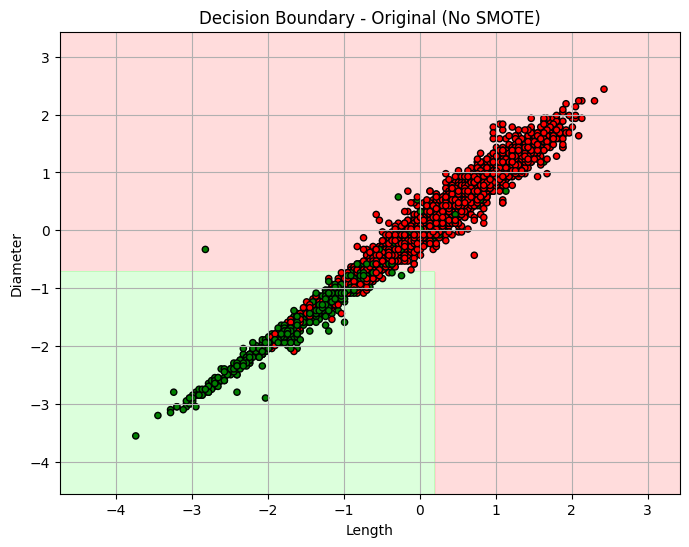

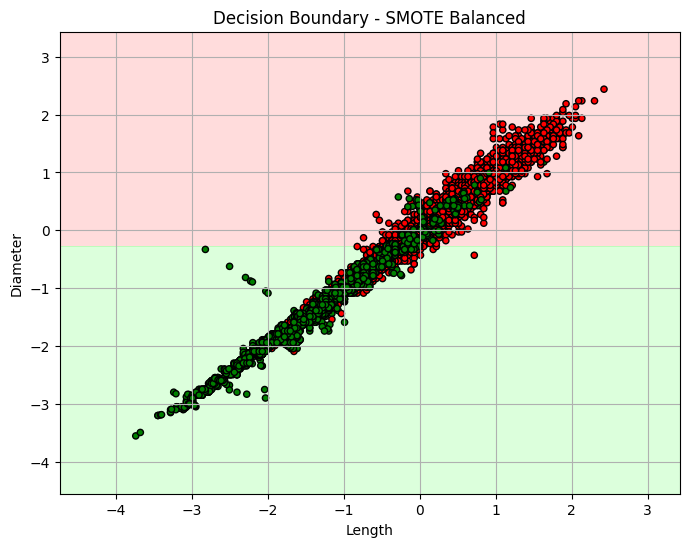

In [181]:
# Original (imbalanced)
plot_boundary(X_vis_scaled, y_vis, "Decision Boundary - Original (No SMOTE)")

# SMOTE-balanced
X_min = X_vis_scaled[y_vis == 1]
y_min = y_vis[y_vis == 1]
X_maj = X_vis_scaled[y_vis == 0]
y_maj = y_vis[y_vis == 0]

N_vis = (len(y_maj) / len(y_min)) - 1
X_syn, y_syn = smote(X_vis_scaled, y_vis, N=N_vis)

X_bal = np.vstack((X_vis_scaled, X_syn))
y_bal = np.hstack((y_vis, y_syn))

plot_boundary(X_bal, y_bal, "Decision Boundary - SMOTE Balanced")
